# Baseline Forecasts

Before neural networks, we need a fair yardstick. This notebook evaluates two simple baselines for next-day Treasury yield changes: zero-change persistence and linear regression.

## Why start with baselines?

Baselines are critical because they make ML research honest. If a complex model cannot beat a simple baseline on the same test set, then the complex model has not earned its complexity.

For daily yield changes, the zero-change baseline is strong because many days have small moves. Linear regression is the next check: can a simple weighted combination of the 60-day feature window predict next-day changes?

In [2]:
# ruff: noqa: E402, I001
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from IPython.display import Image, display

from market_resonance.evaluation import run_baseline_evaluation, save_baseline_results

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "treasury_yields_daily.csv"
RESULTS_PATH = PROJECT_ROOT / "reports" / "tables" / "baseline_results.csv"
FIGURE_PATH = PROJECT_ROOT / "reports" / "figures" / "baseline_rmse_by_maturity.png"

## Run the evaluation

Both models use the same chronological train/validation/test windows from the supervised-window dataset. The linear regression baseline is fit on training data only. The final numbers below are from the test split.

In [3]:
run = run_baseline_evaluation(DATA_PATH, lookback=60, horizon=1)
save_baseline_results(run, RESULTS_PATH, FIGURE_PATH)
run.metrics

,model,maturity,mae_bp,rmse_bp
0,zero_change,overall,3.679,5.457
1,zero_change,3M,1.899,3.513
2,zero_change,6M,2.105,3.641
3,zero_change,1Y,3.223,5.257
4,zero_change,2Y,4.609,6.675
5,zero_change,5Y,4.973,6.674
6,zero_change,10Y,4.708,6.048
7,zero_change,30Y,4.233,5.438
8,linear_regression,overall,3.994,5.679
9,linear_regression,3M,2.523,3.838


## RMSE by maturity

MAE and RMSE are reported in basis points. RMSE is shown below by maturity because it makes it easy to see which parts of the curve are harder to forecast.

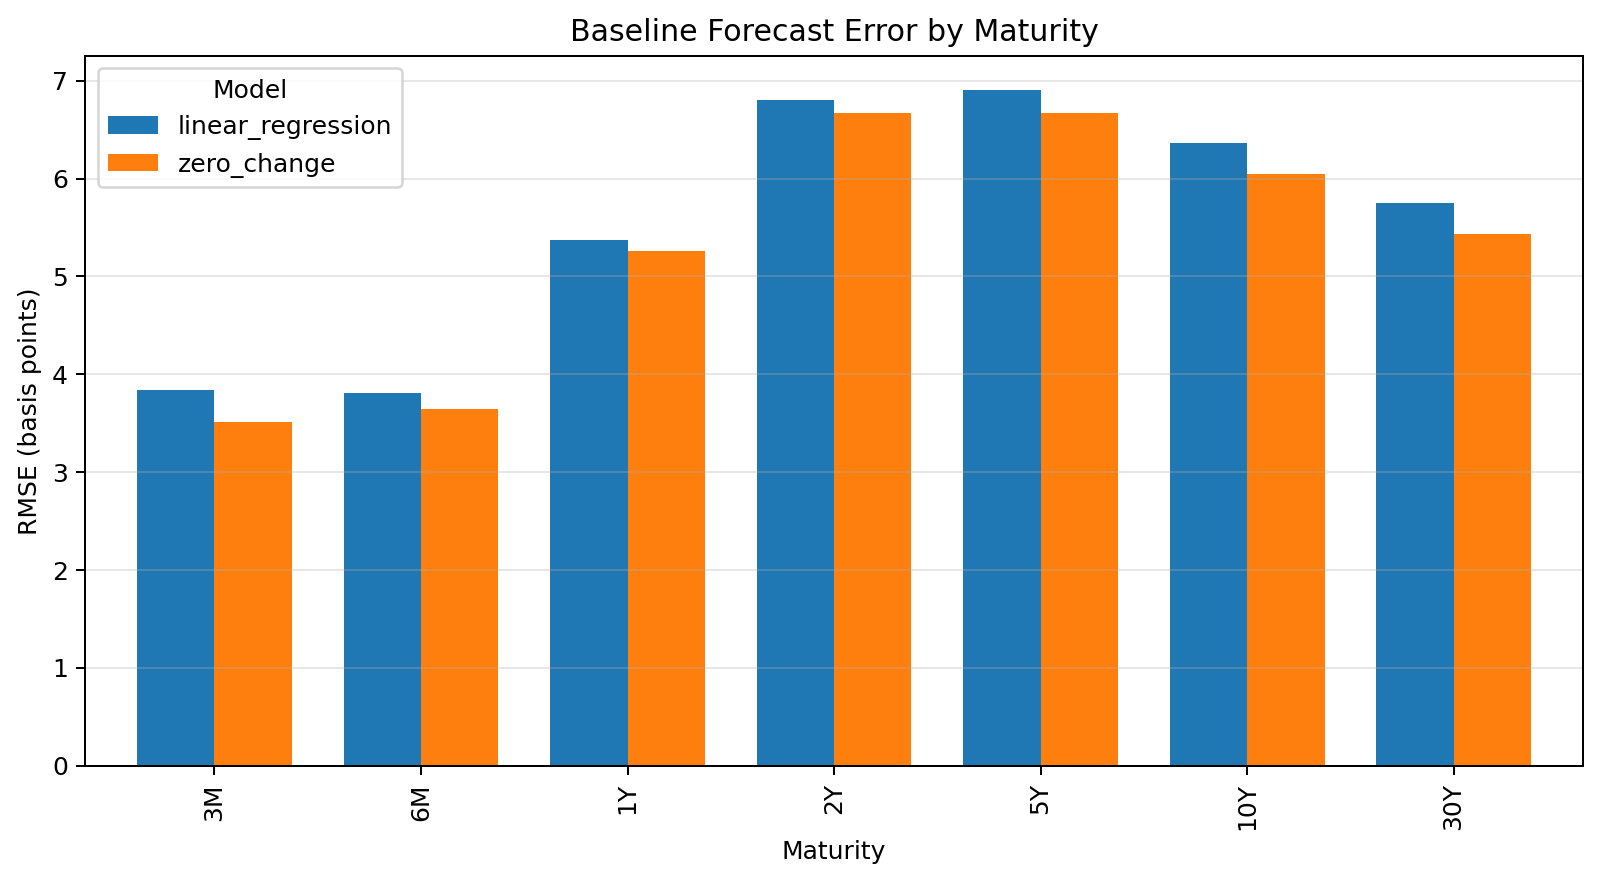

In [4]:
display(Image(filename=FIGURE_PATH))

## Stopping point

We now have baseline performance. The next model must beat these numbers to justify extra complexity. No LSTM is implemented here.